In [1]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# Question 1

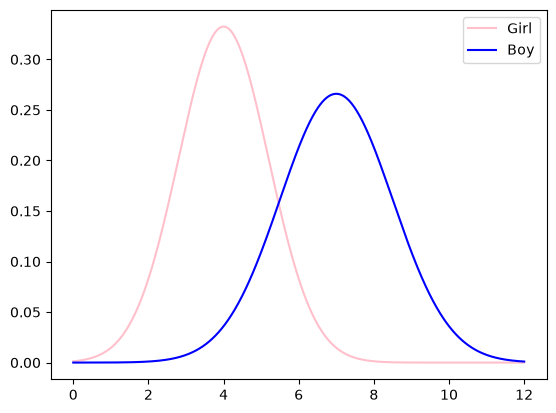

(3500, 1)
(3500,)
Accuracy score: 0.874


In [2]:
np.random.seed(42)
girl_dist = stats.norm(4.0, 1.2)
boy_dist = stats.norm(7.0, 1.5)

x = np.linspace(0, 12, 1000)

plt.plot(x, girl_dist.pdf(x), label="Girl", color="pink")
plt.plot(x, boy_dist.pdf(x), label="Boy", color="blue")
plt.legend()
plt.show()

np.random.seed(42)
n = 5000

X_g = girl_dist.rvs(int(n * 0.7)).reshape(-1, 1)
y_g = np.array([0] * (int(n * 0.7)))
X_b = boy_dist.rvs(int(n * 0.3)).reshape(-1, 1)
y_b = np.array([1] * (int(n * 0.3)))
X = np.vstack((X_g, X_b))
y = np.hstack((y_g, y_b))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
knn = KNeighborsClassifier(n_neighbors=17)
print(X_train.shape)
print(y_train.shape)
knn.fit(X_train, y_train)
print(f"Accuracy score: {knn.score(X_test, y_test)}")

# Quesiton 2

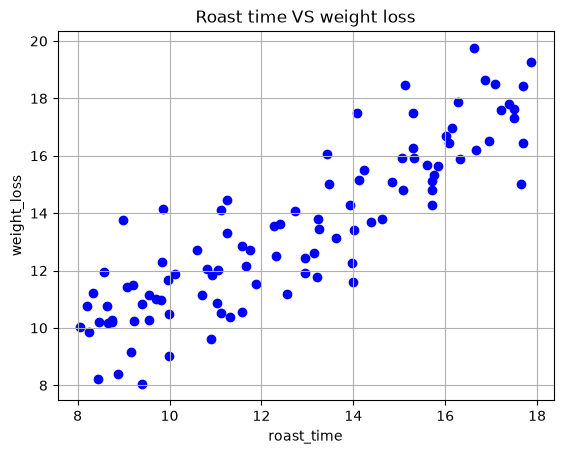

In [3]:
np.random.seed(42)
# n sample
n = 100
# roast time distribution
roast_time = np.random.uniform(8, 18, n)
# bias + weight * roast time + noise
weight_loss = 2.0 + 0.9 * roast_time + np.random.normal(0, 1.5, n)

# scatter plot
plt.scatter(roast_time, weight_loss, c="blue")
plt.title("Roast time VS weight loss")
plt.xlabel("roast_time")
plt.ylabel("weight_loss")
plt.grid()
plt.show()

R2 Score = 0.8072059636181392
MSE = 1.4708239058632542
Intercept = 2.69599320123519
Coeficient = [0.8397971]


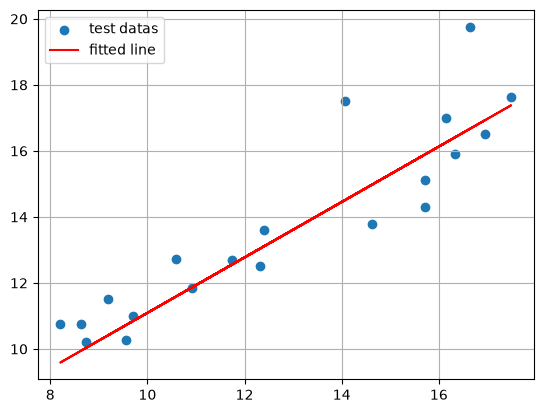

In [4]:
# fit model
Xtrain, Xtest, ytrain, ytest = train_test_split(
    roast_time.reshape(-1, 1), weight_loss, test_size=0.2, random_state=42
)

linear_reg = LinearRegression()
linear_reg.fit(Xtrain, ytrain)

ypred = linear_reg.predict(Xtest)
coef = linear_reg.coef_
intercept = linear_reg.intercept_

mse = mean_squared_error(ytest, ypred)
r2_s = r2_score(ytest, ypred)

print(f"R2 Score = {r2_s}\nMSE = {mse}\nIntercept = {intercept}\nCoeficient = {coef}")

plt.scatter(Xtest, ytest, label="test datas")
plt.plot(Xtest, ypred, c="red", label="fitted line")
plt.legend()
plt.grid()
plt.show()

# More noise

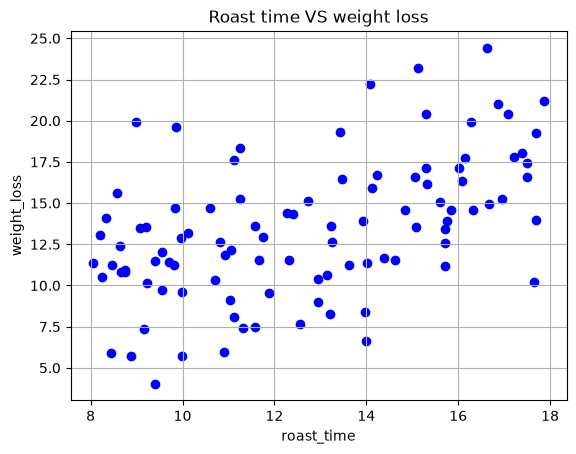

In [5]:
np.random.seed(42)
# n sample
n = 100
# roast time distribution
roast_time = np.random.uniform(8, 18, n)
# bias + weight * roast time + noise
weight_loss = 2.0 + 0.9 * roast_time + np.random.normal(0, 4, n)

# scatter plot
plt.scatter(roast_time, weight_loss, c="blue")
plt.title("Roast time VS weight loss")
plt.xlabel("roast_time")
plt.ylabel("weight_loss")
plt.grid()
plt.show()

R2 Score = 0.22139900300885773
MSE = 10.459192219472033
Intercept = 3.855981869960509
Coeficient = [0.73945893]


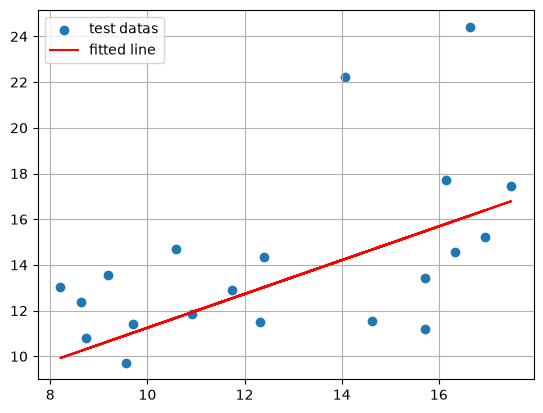

In [6]:
# fit model
Xtrain, Xtest, ytrain, ytest = train_test_split(
    roast_time.reshape(-1, 1), weight_loss, test_size=0.2, random_state=42
)

linear_reg = LinearRegression()
linear_reg.fit(Xtrain, ytrain)

ypred = linear_reg.predict(Xtest)
coef = linear_reg.coef_
intercept = linear_reg.intercept_

mse = mean_squared_error(ytest, ypred)
r2_s = r2_score(ytest, ypred)

print(f"R2 Score = {r2_s}\nMSE = {mse}\nIntercept = {intercept}\nCoeficient = {coef}")

plt.scatter(Xtest, ytest, label="test datas")
plt.plot(Xtest, ypred, c="red", label="fitted line")
plt.legend()
plt.grid()
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler

# Question 3

coef:[6.93127329]
intercept:-8.50175800877608


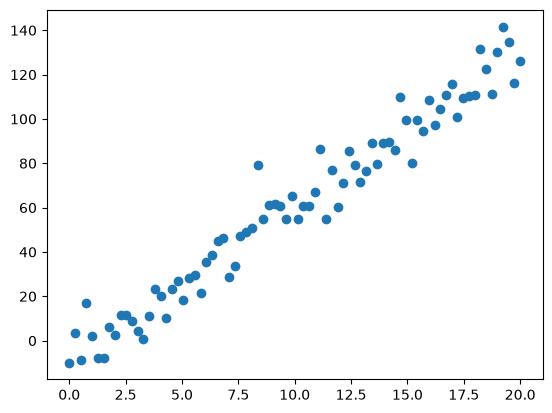

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

x = np.linspace(0, 20, 80)
noise = np.random.normal(0, 8, 80)
y = 7 * x - 10 + noise
model = LinearRegression()
model.fit(x.reshape(-1, 1), y)
print(f"coef:{model.coef_}")
print(f"intercept:{model.intercept_}")
plt.scatter(x, y)
plt.show()

# Question 4

r2_score:0.11677944240246463


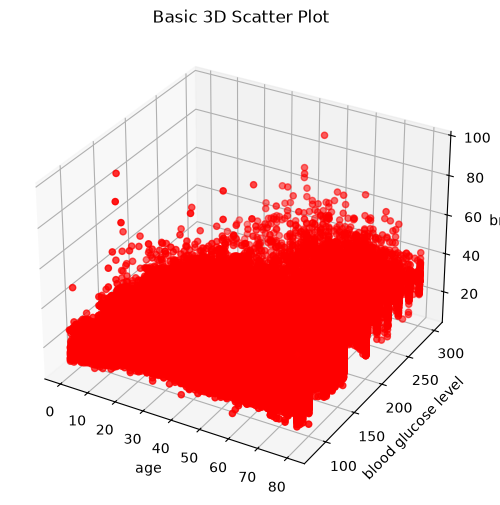

In [9]:
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(r"E:\Maktab-145\Datasets\diabetes_prediction_dataset1.csv")
small_df = df.loc[:, ["age", "blood_glucose_level", "bmi"]]
X = small_df.iloc[:, :-1]
y = small_df.iloc[:, -1]
X_min = np.min(X, axis=0)
X_max = np.max(X, axis=0)
X_scaled = (X - X_min) / (X_max - X_min)
scaler = StandardScaler()
x_standard = scaler.fit_transform(X)
model = LinearRegression()
model.fit(x_standard, y)
y_pred = model.predict(x_standard)
r2 = r2_score(y, y_pred)
print(f"r2_score:{r2}")


x = small_df["age"]
y = small_df["blood_glucose_level"]
z = small_df["bmi"]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter3D(x, y, z, color="red", marker="o")

ax.set_xlabel("age")
ax.set_ylabel("blood glucose level")
ax.set_zlabel("bmi")
ax.set_title("Basic 3D Scatter Plot")

plt.show()

# Question 5

In [ ]:
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

df = pd.read_csv(r"E:\Maktab-145\Datasets\diabetes_prediction_dataset1.csv")

X = df.loc[:, ["HbA1c_level", "bmi", "blood_glucose_level"]]
y = df.iloc[:, -1]

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
model = LogisticRegression()
model.fit(x_train_scaled, y_train)
y_predict1 = model.predict(x_test_scaled)

# accuracy_train = model.score(x_train_scaled, y_train)
# print(f"accuracy train:{accuracy_train}")
accuracy_test = model.score(x_test_scaled, y_test)
print(f"accuracy test:{accuracy_test}")

import pandas as pd
from sklearn.metrics import r2_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

df = pd.read_csv(r"E:\Maktab-145\Datasets\diabetes_dataset2.csv")

X = df.loc[:, ["Age", "GenHlth", "BMI", "HighBP"]]
y = df.iloc[:, -1]
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
model = LogisticRegression()
model.fit(x_train_scaled, y_train)
accuracy_test = model.score(x_test_scaled, y_test)

print(f"accuracy test:{accuracy_test}")
classification_report = classification_report(y_test, model.predict(x_test_scaled))

print(classification_report)

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

conf = confusion_matrix(y_test, y_predict1)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_predict1, display_labels=model.classes_, cmap=plt.cm.Blues
)

plt.title("Confusion Matrix (from_predictions)")
plt.show()

tp = conf[1, 1]
fp = conf[0, 1]
fn = conf[1, 0]
tn = conf[0, 0]

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)
classification_record = classification_report(y_test, y_predict)
print(
    f"precision:{precision}, recall:{recall}, f1_score:{f1_score} classification_record {classification_record}"
)

accuracy test:0.9598
accuracy test:0.3629375591296121
              precision    recall  f1-score   support

         1.0       0.20      0.07      0.10      2943
         2.0       0.16      0.12      0.14      3535
         3.0       0.19      0.00      0.01      4798
         4.0       0.00      0.00      0.00      6041
         5.0       0.17      0.02      0.04      7765
         6.0       0.16      0.04      0.07     10941
         7.0       0.17      0.00      0.00     12966
         8.0       0.38      0.97      0.55     27115

    accuracy                           0.36     76104
   macro avg       0.18      0.15      0.11     76104
weighted avg       0.24      0.36      0.22     76104



e:\Maktab-145\maktab_kernel\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Maktab-145\maktab_kernel\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Maktab-145\maktab_kernel\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


ValueError: Found input variables with inconsistent numbers of samples: [76104, 30000, 76104]

# Question 7

In [ ]:
import numpy as np

p1 = 0.1
p2 = 0.8


def cross_entropy_loss_function(Y, P):
    epsilon = 1e-10
    loss = -np.mean(np.sum(Y * np.log(P + epsilon)))
    return loss


print(cross_entropy_loss_function(y_predict, p1))
print(cross_entropy_loss_function(y_predict, p2))